In [1]:
from google.colab import drive  # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Format floating-point numbers
pd.options.display.float_format = '{:.2f}'.format
drive.mount('/content/drive', force_remount=True)
PATH = '/content/drive/MyDrive/Applied Statistics/Datasets/'

Mounted at /content/drive


In [5]:
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(PATH + 'milan_accident_risk.csv')
df

,high_accident_risk,area_type,average_speed,traffic_density,pedestrian_flow,intersection_density,parking_pressure,public_transport_stop_density,commercial_activity_density,noise_level_db,road_quality_score,lighting_score,crosswalk_density,traffic_calming_devices,bike_lane_density,speed_limit_compliance,green_area_percentage,residential_density,average_road_width,distance_to_city_center
0,1,suburbs,36.20,179.80,1026.50,22.10,75.90,9.80,53.90,67.20,51.10,71.00,13.60,9.30,6.30,80.00,26.70,61.90,6.90,1.90
1,1,inner_city,48.10,142.40,1041.10,19.70,55.50,8.60,56.10,60.60,46.30,63.10,11.10,8.90,1.00,57.10,31.80,93.40,11.50,9.00
2,0,suburbs,38.40,121.80,731.80,16.80,50.30,5.80,36.60,61.80,46.50,70.40,10.30,5.50,3.30,72.00,38.90,107.30,13.60,10.60
3,0,suburbs,56.20,71.80,383.20,12.40,36.30,5.90,15.90,53.70,64.70,82.20,12.50,11.30,5.10,76.50,23.80,70.60,9.20,6.20
4,0,suburbs,42.30,46.30,361.20,8.20,33.60,1.80,21.20,53.40,73.10,78.10,13.70,10.90,5.50,81.30,19.60,31.30,7.60,3.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,0,inner_city,45.40,132.50,426.60,14.30,57.10,6.20,44.70,51.50,73.30,74.30,15.50,11.70,8.60,80.80,24.90,77.50,9.70,7.80
616,0,suburbs,36.60,103.60,910.60,18.00,52.50,9.00,47.90,65.80,99.90,98.70,19.10,15.60,10.30,98.00,31.90,84.50,9.60,3.30
617,0,suburbs,36.20,83.30,763.10,23.30,62.30,7.40,70.50,59.20,58.70,73.40,9.80,8.70,5.10,73.40,17.50,66.20,6.70,2.80
618,1,inner_city,27.40,126.70,820.90,24.30,49.10,6.90,62.40,59.20,35.40,37.60,6.90,2.70,1.00,53.30,15.20,55.20,9.60,2.30


In [6]:
train_df, test_df = train_test_split(df, test_size=0.30,
                                     random_state=123, stratify=df["high_accident_risk"])

In [9]:
PCA_variables = ["traffic_density", "pedestrian_flow",
                 "intersection_density", "parking_pressure", "public_transport_stop_density",
                 "commercial_activity_density", "noise_level_db", "road_quality_score",
                 "lighting_score", "crosswalk_density", "traffic_calming_devices",
                 "bike_lane_density", "speed_limit_compliance", "green_area_percentage",
                 "residential_density", "average_road_width", "distance_to_city_center"]

In [10]:
df[PCA_variables].describe()

,traffic_density,pedestrian_flow,intersection_density,parking_pressure,public_transport_stop_density,commercial_activity_density,noise_level_db,road_quality_score,lighting_score,crosswalk_density,traffic_calming_devices,bike_lane_density,speed_limit_compliance,green_area_percentage,residential_density,average_road_width,distance_to_city_center
count,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00,620.00
mean,119.33,794.12,17.76,54.25,7.33,44.47,61.74,62.97,67.04,12.24,8.13,5.13,72.69,24.09,65.95,8.48,5.54
std,38.96,260.48,5.64,16.76,2.42,16.01,6.71,13.33,14.65,3.79,3.20,2.04,11.23,9.55,18.35,2.75,3.15
min,20.00,100.00,4.00,10.00,1.00,5.00,42.00,24.20,24.00,2.00,0.00,0.00,34.60,2.00,10.00,3.00,0.20
25%,94.45,630.72,14.10,42.60,5.80,34.27,57.80,53.20,56.50,9.90,6.00,3.80,65.88,17.77,52.98,6.47,3.30
50%,118.80,794.75,17.75,54.25,7.30,44.50,61.50,62.50,67.20,12.10,8.10,5.10,72.35,23.50,64.80,8.65,5.30
75%,143.93,962.05,21.70,65.12,8.90,54.23,66.43,72.62,77.33,14.70,10.40,6.50,80.15,30.32,78.10,10.30,7.70
max,230.00,1600.00,33.90,100.00,16.00,94.90,82.00,100.00,100.00,25.70,18.00,11.60,100.00,54.10,120.00,16.90,15.00


In [11]:
from sklearn.preprocessing import StandardScaler
# Preprocessing
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(
    train_df[PCA_variables]), columns=train_df[PCA_variables].columns, index=train_df[PCA_variables].index)

In [ ]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(random_state=33)
scores = pca.fit_transform(X)

array([[ 0.58481244, -3.44150325, -2.72737447, ...,  0.16892559,
        -0.68149877,  0.19733044],
       [ 0.54999901,  0.28896094, -1.63018325, ..., -0.40283629,
         0.5352469 ,  0.37162738],
       [ 1.32984883,  0.191914  ,  1.15234818, ...,  0.09818599,
        -0.3005455 , -0.41895225],
       ...,
       [ 0.82618149,  3.57717101, -1.25411682, ...,  0.68906291,
         0.04439985,  0.04677706],
       [-0.06586646, -2.79674624, -0.3108404 , ..., -0.20128045,
         0.04843853, -0.28454787],
       [ 1.09202298,  0.50114459,  0.43607237, ...,  0.27078476,
         0.0797917 ,  0.55173882]])

In [24]:
df_ev = pd.DataFrame(pca.explained_variance_)
df_ev.to_excel("ev.xlsx")

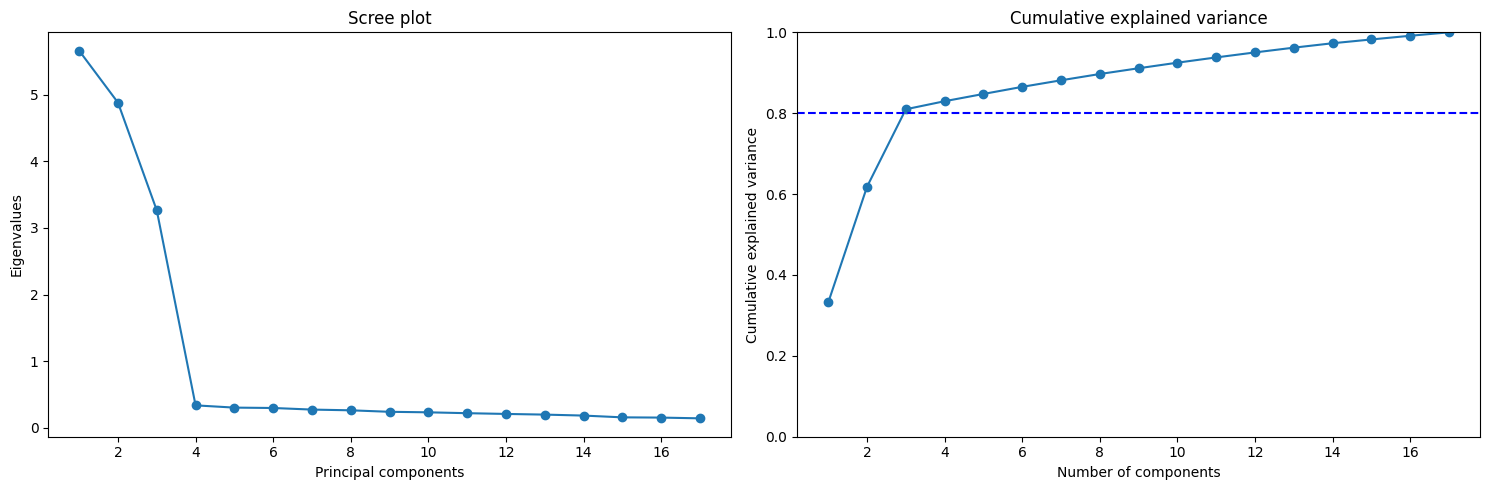

In [22]:
import numpy as np
n, p = X.shape

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(np.arange(1, p+1),
            pca.explained_variance_, marker='o')
axs[0].set_title('Scree plot')
axs[0].set_xlabel('Principal components')
axs[0].set_ylabel('Eigenvalues')

cum_explained = np.cumsum(pca.explained_variance_ratio_)

axs[1].plot(np.arange(1, p+1), cum_explained, marker='o')
axs[1].axhline(0.8, color='blue', linestyle='--')
axs[1].set_xlabel('Number of components')
axs[1].set_ylabel('Cumulative explained variance')
axs[1].set_title('Cumulative explained variance')
axs[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig("scree_plot.png")
plt.show()

/tmp/ipykernel_1684/720109529.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(X.columns, rotation=90)
/tmp/ipykernel_1684/720109529.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(X.columns, rotation=90)
/tmp/ipykernel_1684/720109529.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(X.columns, rotation=90)


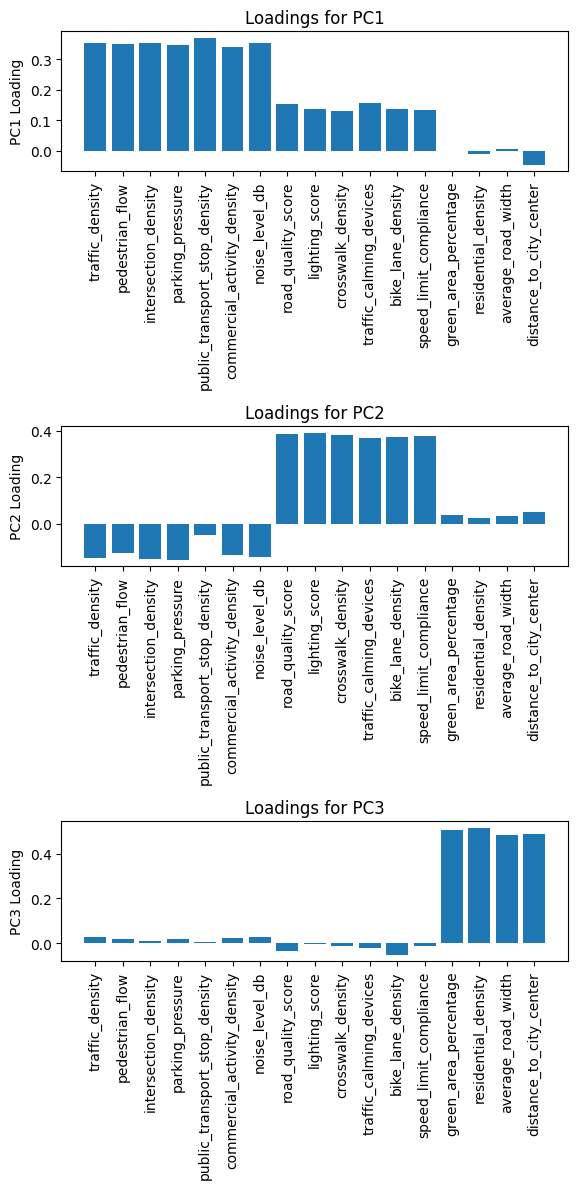

In [19]:
loadings = pca.components_.T
fig, axes = plt.subplots(3, 1, figsize=(6, 12))

for i, ax in enumerate(axes):
    ax.bar(X.columns, loadings[:, i])
    ax.set_xticklabels(X.columns, rotation=90)
    ax.set_ylabel(f"PC{i+1} Loading")
    ax.set_title(f"Loadings for PC{i+1}")

plt.tight_layout()
plt.savefig("loadings.png")
plt.show()

In [37]:
# Logistic regression
train_index = train_df.index
test_index = test_df.index

In [39]:
train_df["area_type"].value_counts()

,count
area_type,
suburbs,234
inner_city,200


In [ ]:
variables = ["traffic_flow", "traffic_safety",
             "urban_composition", "area_type", "average_speed"]
PCA_scores = pd.DataFrame(scores[:, :3], index=train_df.index, columns=[
                          "traffic_flow", "traffic_safety", "urban_composition"])
TARGET = "high_accident_risk"
add_predictors = train_df[["area_type", "average_speed"]]
X_train = pd.DataFrame(
    np.hstack([PCA_scores, add_predictors]), index=train_index, columns=variables)

X_train_enc = pd.get_dummies(
    X_train, columns=["area_type"], drop_first=True, dtype=int)
interaction = X_train_enc["area_type_suburbs"] * X_train_enc["average_speed"]